# 🔍 Audit Financier & Détection d'Anomalies
## Classification des Risques d'Audit par Cycle Comptable

---

**Projet :** Classification des risques d'audit financier  
**Référentiel :** Normes ISA + Guides OECCA Maroc (Plan Comptable Général Marocain)  
**Objectif :** Approche par les risques en audit, feature engineering sur indicateurs financiers, planification des missions  
**Cycles analysés :** Ventes, Achats, Trésorerie, Paie, Stocks, Immobilisations, Fiscalité, Capitaux propres

---

### Plan du notebook
1. Installation & Imports
2. Chargement & Exploration des données
3. Feature Engineering
4. Analyse exploratoire (EDA)
5. Préparation des données pour la modélisation
6. Modèles de classification (ML)
7. Évaluation & Comparaison des modèles
8. Matrice de risque & Cartographie
9. Planification des missions d'audit
10. Export des résultats

## 1. 📦 Installation & Imports

In [7]:
# ============================================================
# INSTALLATION DES DÉPENDANCES (Google Colab)
# ============================================================
# Décommentez la ligne suivante si vous exécutez sur Google Colab
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl imbalanced-learn xgboost shap -q

# ============================================================
# IMPORTS PRINCIPAUX
# ============================================================

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning - Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Machine Learning - Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Machine Learning - Métriques
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

# Gestion des classes déséquilibrées
from sklearn.utils.class_weight import compute_class_weight

# Chargement fichier Excel
import openpyxl

# Avertissements
import warnings
warnings.filterwarnings('ignore')

# Configuration globale des graphiques
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Toutes les bibliothèques sont chargées avec succès.')

✅ Toutes les bibliothèques sont chargées avec succès.


## 2. 📂 Chargement & Exploration des données

In [8]:
# ============================================================
# CHARGEMENT DU FICHIER
# ============================================================
# Sur Google Colab : uploadez le fichier via la cellule ci-dessous
# Décommentez si nécessaire :
# from google.colab import files
# uploaded = files.upload()

# Chargement du fichier Excel
FICHIER = '/content/drive/MyDrive/projet 2026/base_donnees_risques_audit_cycle_comptable.xlsx'

df = pd.read_excel(FICHIER, sheet_name='Audit_Risks_DB')

print(f'📊 Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'📋 Colonnes disponibles :\n')
for col in df.columns:
    print(f'   • {col}')

📊 Dimensions du dataset : 220 lignes × 10 colonnes
📋 Colonnes disponibles :

   • ID
   • Cycle comptable
   • Processus
   • Compte concerné (PCG Maroc)
   • Description du risque
   • Type de risque
   • Assertion impactée
   • Niveau de risque
   • Procédure d’audit
   • Documents de preuve


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ============================================================
# APERÇU DES PREMIÈRES LIGNES
# ============================================================
df.head(10)

,ID,Cycle comptable,Processus,Compte concerné (PCG Maroc),Description du risque,Type de risque,Assertion impactée,Niveau de risque,Procédure d’audit,Documents de preuve
0,R001,Ventes - Clients,Facturation,"711,342",Factures fictives,Contrôle,Existence,Moyen,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
1,R002,Ventes - Clients,Facturation,711,Omission de ventes,Fraude,Exhaustivité,Élevé,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
2,R003,Ventes - Clients,Encaissement,"514,342",Détournement de paiement client,Inhérent,Existence,Faible,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
3,R004,Ventes - Clients,Créances,342,Créances douteuses non provisionnées,Contrôle,Évaluation,Moyen,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
4,R005,Ventes - Clients,Cut-off ventes,711,Ventes enregistrées dans la mauvaise période,Fraude,Cut-off,Élevé,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
5,R006,Ventes - Clients,Facturation,"711,342",Factures fictives,Inhérent,Existence,Faible,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
6,R007,Ventes - Clients,Facturation,711,Omission de ventes,Contrôle,Exhaustivité,Moyen,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
7,R008,Ventes - Clients,Encaissement,"514,342",Détournement de paiement client,Fraude,Existence,Élevé,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
8,R009,Ventes - Clients,Créances,342,Créances douteuses non provisionnées,Inhérent,Évaluation,Faible,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"
9,R010,Ventes - Clients,Cut-off ventes,711,Ventes enregistrées dans la mauvaise période,Contrôle,Cut-off,Moyen,Procédure d’audit à définir (test de contrôle ...,"Factures, contrats, relevés bancaires"


In [11]:
# ============================================================
# INFORMATIONS GÉNÉRALES SUR LE DATASET
# ============================================================
print('=== TYPES DE DONNÉES ===')
print(df.dtypes)
print()
print('=== VALEURS MANQUANTES ===')
print(df.isnull().sum())
print()
print('=== STATISTIQUES DESCRIPTIVES (variables catégorielles) ===')
print(df.describe(include='object'))

=== TYPES DE DONNÉES ===
ID                             object
Cycle comptable                object
Processus                      object
Compte concerné (PCG Maroc)    object
Description du risque          object
Type de risque                 object
Assertion impactée             object
Niveau de risque               object
Procédure d’audit              object
Documents de preuve            object
dtype: object

=== VALEURS MANQUANTES ===
ID                             0
Cycle comptable                0
Processus                      0
Compte concerné (PCG Maroc)    0
Description du risque          0
Type de risque                 0
Assertion impactée             0
Niveau de risque               0
Procédure d’audit              0
Documents de preuve            0
dtype: int64

=== STATISTIQUES DESCRIPTIVES (variables catégorielles) ===
          ID   Cycle comptable    Processus Compte concerné (PCG Maroc)  \
count    220               220          220                         220   

In [12]:
# ============================================================
# VALEURS UNIQUES PAR VARIABLE CLÉ
# ============================================================
cles = ['Cycle comptable', 'Type de risque', 'Assertion impactée', 'Niveau de risque']

for col in cles:
    print(f'\n🔑 {col} ({df[col].nunique()} modalités) :')
    for val in sorted(df[col].unique()):
        count = df[col].value_counts()[val]
        pct   = count / len(df) * 100
        print(f'   {val:<35} → {count:>3} occurrences ({pct:.1f}%)')


🔑 Cycle comptable (8 modalités) :
   Achats - Fournisseurs               →  30 occurrences (13.6%)
   Capitaux propres                    →  10 occurrences (4.5%)
   Fiscalité                           →  30 occurrences (13.6%)
   Immobilisations                     →  30 occurrences (13.6%)
   Paie                                →  30 occurrences (13.6%)
   Stocks                              →  30 occurrences (13.6%)
   Trésorerie                          →  30 occurrences (13.6%)
   Ventes - Clients                    →  30 occurrences (13.6%)

🔑 Type de risque (3 modalités) :
   Contrôle                            →  74 occurrences (33.6%)
   Fraude                              →  73 occurrences (33.2%)
   Inhérent                            →  73 occurrences (33.2%)

🔑 Assertion impactée (6 modalités) :
   Autorisation                        →   6 occurrences (2.7%)
   Cut-off                             →  18 occurrences (8.2%)
   Exhaustivité                        →  54 occurr

## 3. ⚙️ Feature Engineering

> Le **feature engineering** en audit consiste à construire des indicateurs synthétiques à partir des caractéristiques brutes des risques.
> Ces features s'inspirent des diligences ISA 315 (identification des risques) et ISA 330 (réponses aux risques évalués).

In [13]:
# ============================================================
# FEATURE 1 : Encodage ordinal du niveau de risque
# Justification ISA : l'évaluation du risque d'anomalies
# significatives repose sur une échelle ordinale (ISA 315.25)
# ============================================================
risque_map = {'Faible': 0, 'Moyen': 1, 'Élevé': 2}
df['risque_score'] = df['Niveau de risque'].map(risque_map)

# ============================================================
# FEATURE 2 : Score de criticité par type de risque
# - Risque inhérent : risque naturel lié à l'activité (ISA 200)
# - Risque de contrôle : inefficacité du contrôle interne
# - Risque de fraude : intentionnalité → coefficient plus élevé
# ============================================================
type_risque_score = {'Inhérent': 1, 'Contrôle': 2, 'Fraude': 3}
df['type_risque_score'] = df['Type de risque'].map(type_risque_score)

# ============================================================
# FEATURE 3 : Score d'assertion
# Certaines assertions sont jugées plus sensibles en pratique
# Existence & Exhaustivité = cœur des manipulations comptables
# ============================================================
assertion_score = {
    'Existence': 3,
    'Exhaustivité': 3,
    'Évaluation': 2,
    'Cut-off': 2,
    'Autorisation': 1,
    'Présentation': 1
}
df['assertion_score'] = df['Assertion impactée'].map(assertion_score)

# ============================================================
# FEATURE 4 : Indice de risque combiné (IRC)
# Formule inspirée du modèle de risque d'audit :
# Risque d'audit = Risque inhérent × Risque contrôle × Risque détection
# On approxime par un score composite normalisé
# ============================================================
df['IRC'] = (df['type_risque_score'] * df['assertion_score']) / (
    df['type_risque_score'].max() * df['assertion_score'].max()
)

# ============================================================
# FEATURE 5 : Complexité du cycle comptable
# Basé sur le nombre de processus distincts par cycle
# ============================================================
complexite_cycle = df.groupby('Cycle comptable')['Processus'].nunique()
df['complexite_cycle'] = df['Cycle comptable'].map(complexite_cycle)

# ============================================================
# FEATURE 6 : Nombre de comptes PCG concernés
# Un risque touchant plusieurs comptes est plus difficile à auditer
# ============================================================
df['nb_comptes_pcg'] = df['Compte concerné (PCG Maroc)'].astype(str).str.count(',') + 1

# ============================================================
# FEATURE 7 : Encodage one-hot des cycles comptables
# ============================================================
df_encoded = pd.get_dummies(df, columns=['Cycle comptable', 'Type de risque', 'Assertion impactée'],
                             prefix=['cycle', 'type', 'assertion'])

print('✅ Feature engineering terminé. Nouvelles variables créées :')
nouvelles = ['risque_score','type_risque_score','assertion_score','IRC','complexite_cycle','nb_comptes_pcg']
print(df[nouvelles].describe().round(3))

✅ Feature engineering terminé. Nouvelles variables créées :
       risque_score  type_risque_score  assertion_score      IRC  \
count       220.000            220.000          220.000  220.000   
mean          1.000              2.000            2.500    0.557   
std           0.816              0.816            0.601    0.270   
min           0.000              1.000            1.000    0.111   
25%           0.000              1.000            2.000    0.333   
50%           1.000              2.000            3.000    0.667   
75%           2.000              3.000            3.000    0.667   
max           2.000              3.000            3.000    1.000   

       complexite_cycle  nb_comptes_pcg  
count           220.000         220.000  
mean              4.864           1.082  
std               0.344           0.275  
min               4.000           1.000  
25%               5.000           1.000  
50%               5.000           1.000  
75%               5.000          

In [14]:
# ============================================================
# FEATURE 8 : Priorité de diligence (planification mission)
# Combine le niveau de risque + type + assertion
# Sert à prioriser l'ordre des tests d'audit
# ============================================================
df['priorite_audit'] = (
    df['risque_score'] * 0.5 +
    df['type_risque_score'] * 0.3 +
    df['assertion_score'] * 0.2
)

# Découpage en 3 niveaux de priorité
df['priorite_label'] = pd.cut(
    df['priorite_audit'],
    bins=3,
    labels=['Priorité 3 (Faible)', 'Priorité 2 (Normale)', 'Priorité 1 (Urgente)']
)

print('Distribution des priorités de mission :')
print(df['priorite_label'].value_counts())

Distribution des priorités de mission :
priorite_label
Priorité 2 (Normale)    74
Priorité 3 (Faible)     73
Priorité 1 (Urgente)    73
Name: count, dtype: int64


## 4. 📊 Analyse Exploratoire des Données (EDA)

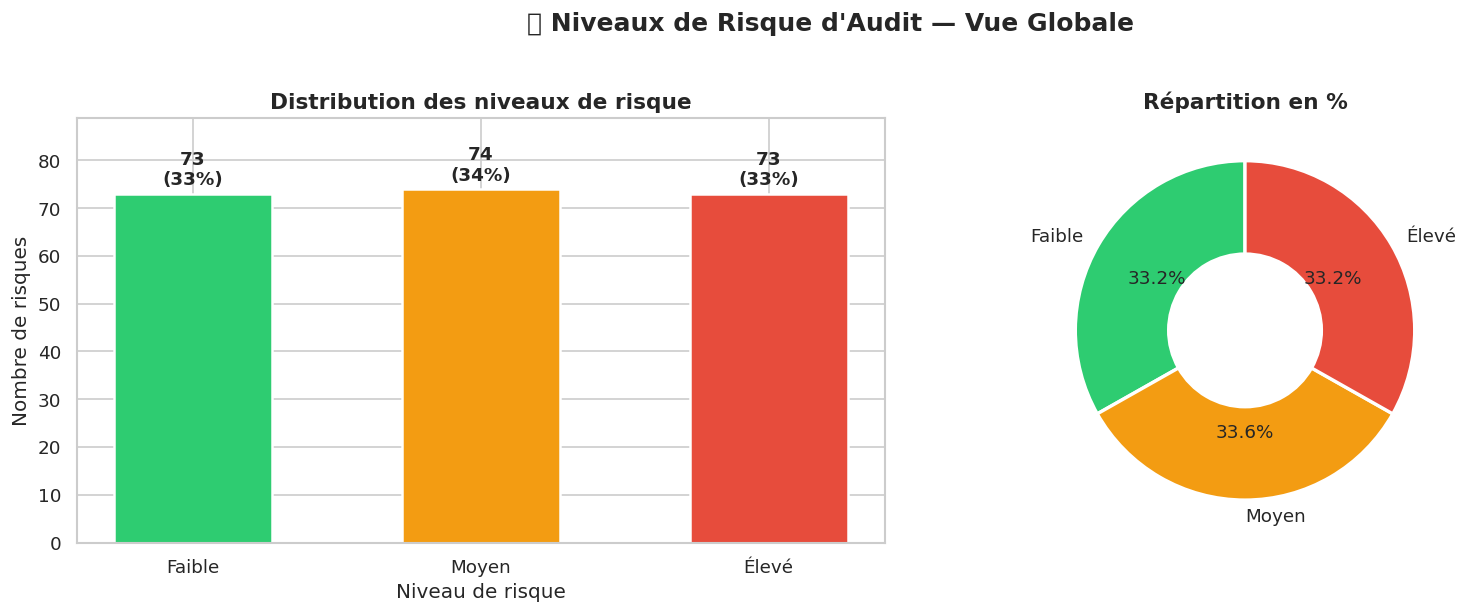

In [15]:
# ============================================================
# DISTRIBUTION GLOBALE DES NIVEAUX DE RISQUE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palette de couleurs sémantique (vert=faible, orange=moyen, rouge=élevé)
couleurs_risque = {'Faible': '#2ecc71', 'Moyen': '#f39c12', 'Élevé': '#e74c3c'}
ordre_risque    = ['Faible', 'Moyen', 'Élevé']

# Graphique en barres
counts = df['Niveau de risque'].value_counts()[ordre_risque]
bars = axes[0].bar(counts.index, counts.values,
                   color=[couleurs_risque[r] for r in counts.index],
                   edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}\n({val/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution des niveaux de risque', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Niveau de risque')
axes[0].set_ylabel('Nombre de risques')
axes[0].set_ylim(0, counts.max() * 1.2)

# Camembert
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[couleurs_risque[r] for r in counts.index],
            wedgeprops=wedge_props, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Répartition en %', fontsize=13, fontweight='bold')

plt.suptitle('🔴 Niveaux de Risque d\'Audit — Vue Globale', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig01_distribution_risque.png', bbox_inches='tight', dpi=150)
plt.show()

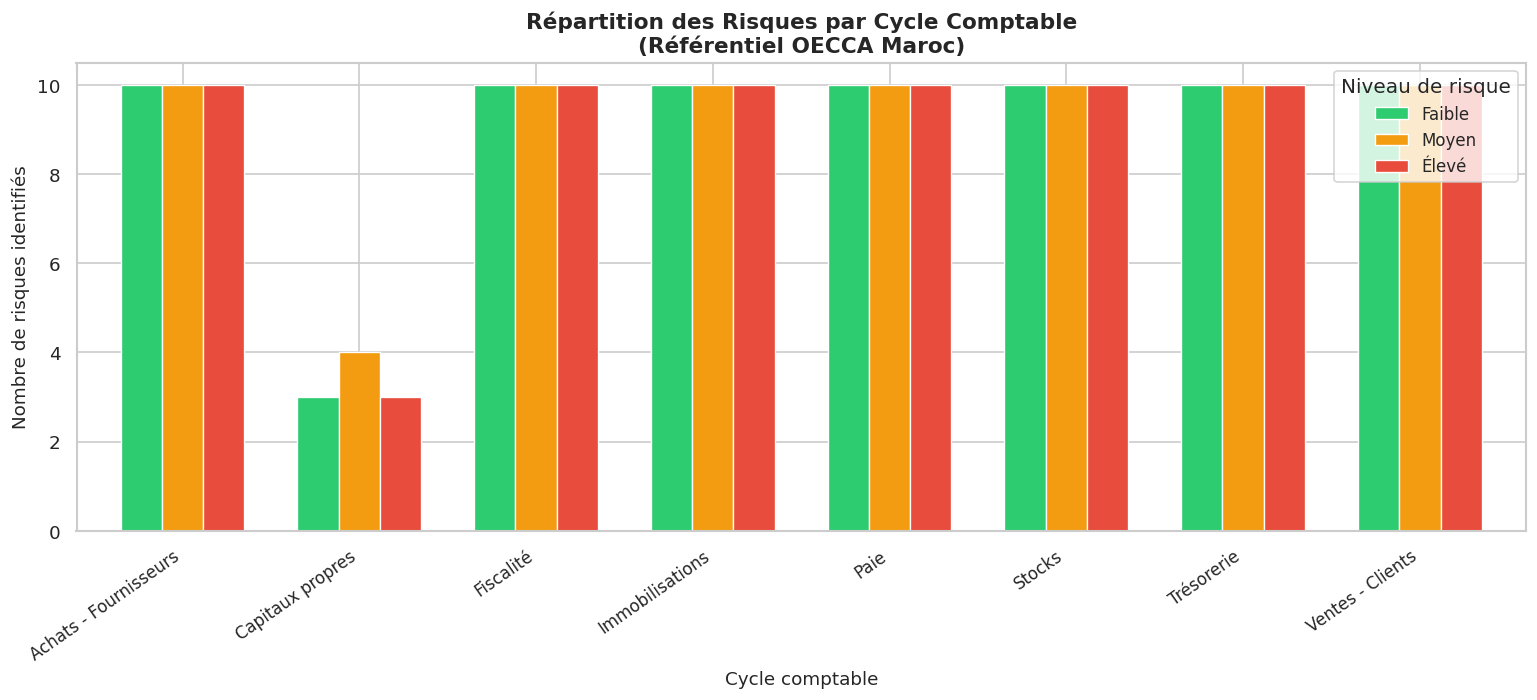


📋 Tableau détaillé :
Niveau de risque       Faible  Moyen  Élevé
Cycle comptable                            
Achats - Fournisseurs      10     10     10
Capitaux propres            3      4      3
Fiscalité                  10     10     10
Immobilisations            10     10     10
Paie                       10     10     10
Stocks                     10     10     10
Trésorerie                 10     10     10
Ventes - Clients           10     10     10


In [16]:
# ============================================================
# RÉPARTITION DES RISQUES PAR CYCLE COMPTABLE
# ============================================================
pivot = df.groupby(['Cycle comptable', 'Niveau de risque']).size().unstack(fill_value=0)
pivot = pivot[ordre_risque]  # Ordre logique

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax,
           color=[couleurs_risque[r] for r in ordre_risque],
           edgecolor='white', linewidth=0.8, width=0.7)

ax.set_title('Répartition des Risques par Cycle Comptable\n(Référentiel OECCA Maroc)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cycle comptable', fontsize=11)
ax.set_ylabel('Nombre de risques identifiés', fontsize=11)
ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=10)
ax.legend(title='Niveau de risque', fontsize=10)

plt.tight_layout()
plt.savefig('fig02_risques_par_cycle.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📋 Tableau détaillé :')
print(pivot)

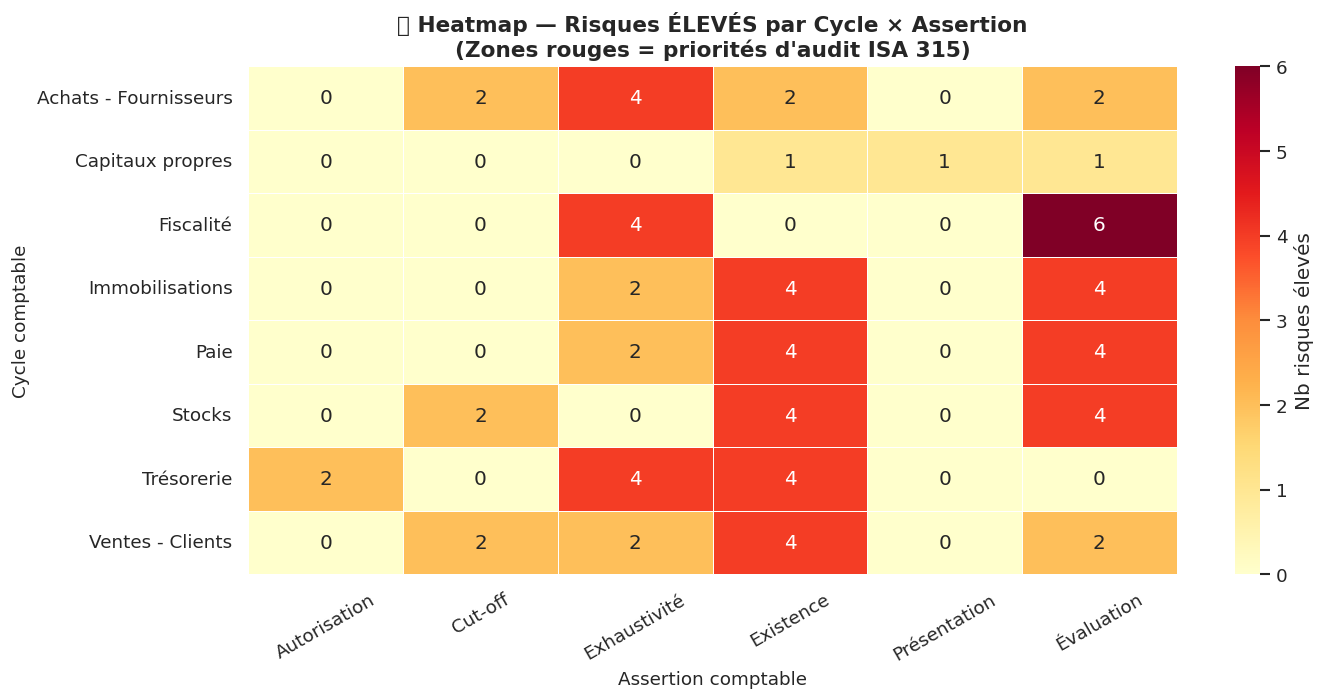

In [17]:
# ============================================================
# HEATMAP : CYCLE × ASSERTION — DENSITÉ DE RISQUES ÉLEVÉS
# Permet d'identifier les zones à fort risque pour prioriser
# la planification des procédures d'audit (ISA 300)
# ============================================================
df_eleve = df[df['Niveau de risque'] == 'Élevé']
heatmap_data = df_eleve.groupby(['Cycle comptable', 'Assertion impactée']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': "Nb risques élevés"},
            ax=ax)
ax.set_title('🌡️ Heatmap — Risques ÉLEVÉS par Cycle × Assertion\n(Zones rouges = priorités d\'audit ISA 315)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Assertion comptable', fontsize=11)
ax.set_ylabel('Cycle comptable', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig03_heatmap_assertions.png', bbox_inches='tight', dpi=150)
plt.show()

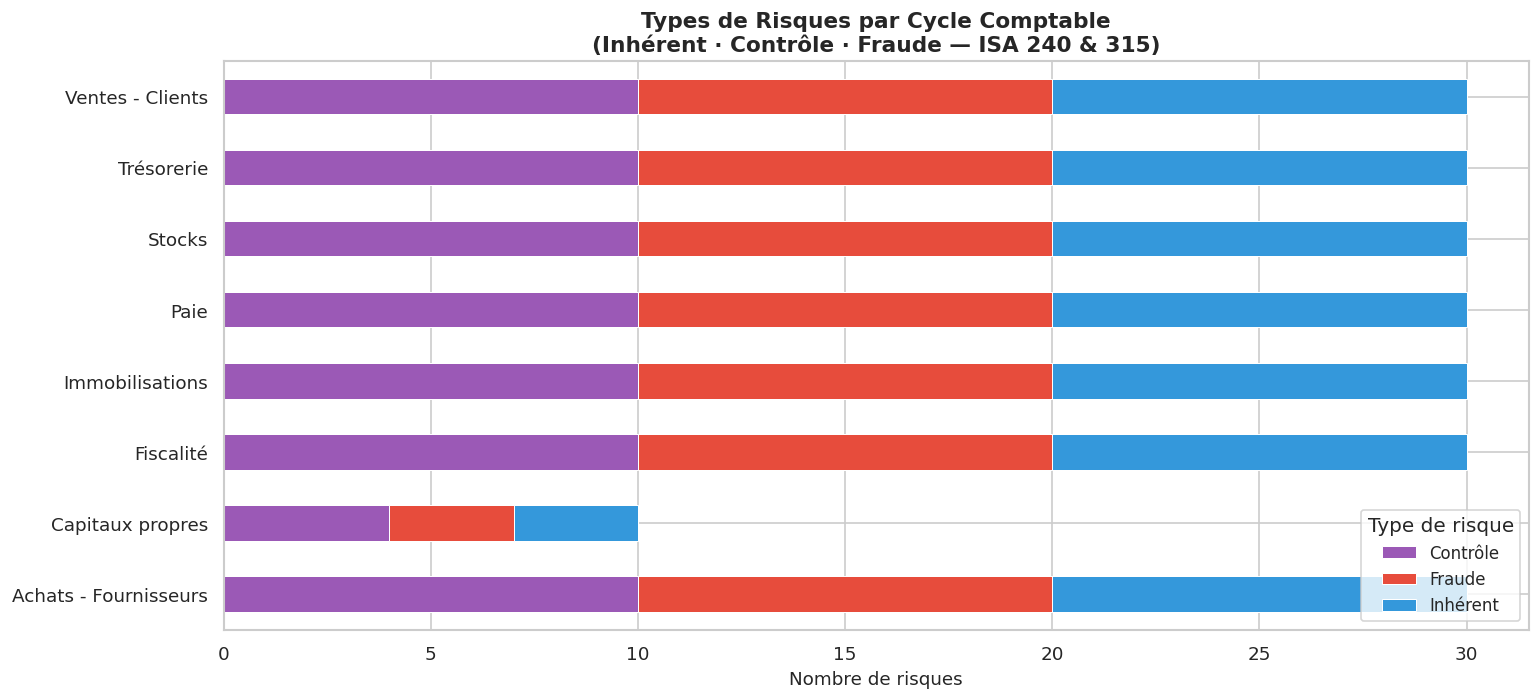

In [18]:
# ============================================================
# DISTRIBUTION DES TYPES DE RISQUE PAR CYCLE
# Inhérent / Contrôle / Fraude — ISA 240 & 315
# ============================================================
pivot_type = df.groupby(['Cycle comptable', 'Type de risque']).size().unstack(fill_value=0)
couleurs_type = {'Inhérent': '#3498db', 'Contrôle': '#9b59b6', 'Fraude': '#e74c3c'}

fig, ax = plt.subplots(figsize=(13, 6))
pivot_type.plot(kind='barh', ax=ax, stacked=True,
                color=[couleurs_type[t] for t in pivot_type.columns],
                edgecolor='white', linewidth=0.6)
ax.set_title('Types de Risques par Cycle Comptable\n(Inhérent · Contrôle · Fraude — ISA 240 & 315)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre de risques', fontsize=11)
ax.set_ylabel('')
ax.legend(title='Type de risque', loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('fig04_types_risques.png', bbox_inches='tight', dpi=150)
plt.show()

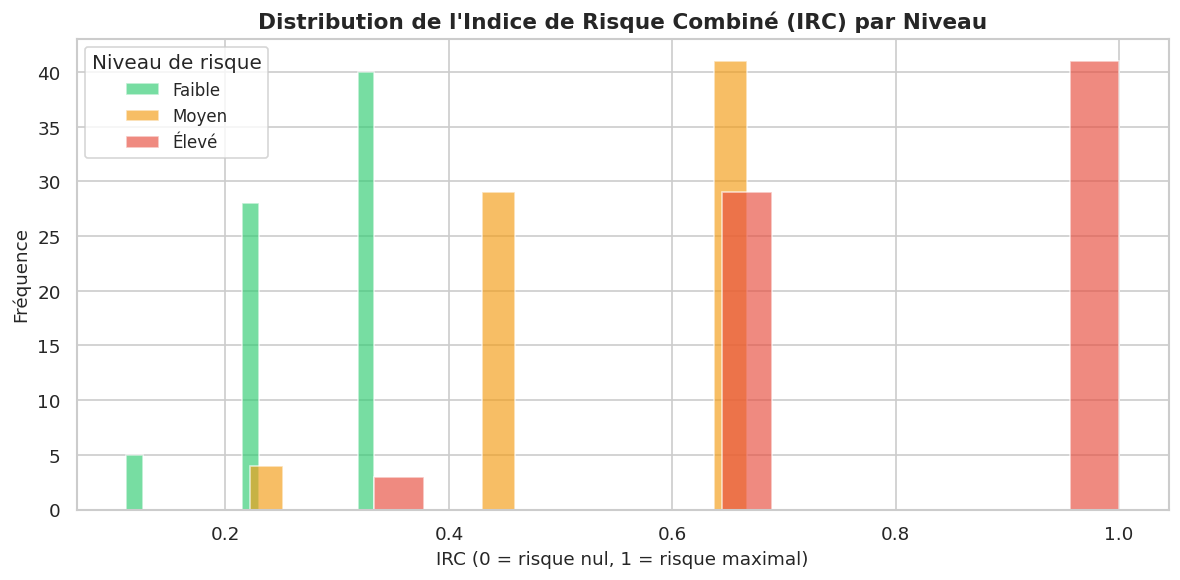

In [19]:
# ============================================================
# DISTRIBUTION DE L'INDICE DE RISQUE COMBINÉ (IRC)
# Feature engineerée — visualisation par niveau de risque
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

for niveau in ordre_risque:
    subset = df[df['Niveau de risque'] == niveau]['IRC']
    ax.hist(subset, bins=15, alpha=0.65, label=niveau,
            color=couleurs_risque[niveau], edgecolor='white')

ax.set_title('Distribution de l\'Indice de Risque Combiné (IRC) par Niveau',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IRC (0 = risque nul, 1 = risque maximal)', fontsize=11)
ax.set_ylabel('Fréquence', fontsize=11)
ax.legend(title='Niveau de risque', fontsize=10)

plt.tight_layout()
plt.savefig('fig05_irc_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. 🛠️ Préparation des données pour la modélisation

> **Variable cible** : `Niveau de risque` (Faible / Moyen / Élevé) → classification multi-classe  
> **Approche** : supervisée, basée sur les features engineerées + encodages catégoriels

In [20]:
# ============================================================
# SÉLECTION DES FEATURES POUR LES MODÈLES
# ============================================================

# Encodage de la cible
le_target = LabelEncoder()
y = le_target.fit_transform(df['Niveau de risque'])  # Faible=0, Moyen=1, Élevé=2

print('Classes encodées :', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Features numériques issues du feature engineering
features_numeriques = [
    'type_risque_score',    # Type de risque encodé
    'assertion_score',      # Criticité de l'assertion
    'IRC',                  # Indice de risque combiné
    'complexite_cycle',     # Complexité du cycle
    'nb_comptes_pcg',       # Nombre de comptes PCG touchés
    'priorite_audit'        # Score de priorité
]

# Encodage one-hot des variables catégorielles
features_cat = ['Cycle comptable', 'Type de risque', 'Assertion impactée']
df_ohe = pd.get_dummies(df[features_cat], drop_first=False)

# Matrice X finale
X = pd.concat([df[features_numeriques], df_ohe], axis=1)

print(f'\n✅ Matrice X : {X.shape[0]} observations × {X.shape[1]} features')
print(f'   → {len(features_numeriques)} features numériques + {df_ohe.shape[1]} features one-hot')

Classes encodées : {'Faible': np.int64(0), 'Moyen': np.int64(1), 'Élevé': np.int64(2)}

✅ Matrice X : 220 observations × 23 features
   → 6 features numériques + 17 features one-hot


In [21]:
# ============================================================
# DIVISION TRAIN / TEST (80% / 20%)
# Stratification pour conserver l'équilibre des classes
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Normalisation (utile pour LR et SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'📦 Taille du jeu d\'entraînement : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'📦 Taille du jeu de test        : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Distribution des classes dans Train :')
for cls, cnt in zip(le_target.classes_, np.bincount(y_train)):
    print(f'   {cls:<10}: {cnt}')
print()
print('Distribution des classes dans Test :')
for cls, cnt in zip(le_target.classes_, np.bincount(y_test)):
    print(f'   {cls:<10}: {cnt}')

📦 Taille du jeu d'entraînement : 176 (80%)
📦 Taille du jeu de test        : 44 (20%)

Distribution des classes dans Train :
   Faible    : 58
   Moyen     : 59
   Élevé     : 59

Distribution des classes dans Test :
   Faible    : 15
   Moyen     : 15
   Élevé     : 14


## 6. 🤖 Modèles de Classification ML

In [22]:
# ============================================================
# DÉFINITION DES MODÈLES À COMPARER
# ============================================================
# 5 modèles représentatifs couvrant différentes familles :
#   • Modèle linéaire    : Régression logistique
#   • Arbre de décision  : CART (Decision Tree)
#   • Ensemble           : Random Forest, Gradient Boosting
#   • Instance-based     : KNN

modeles = {
    'Régression Logistique':    LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'),
    'Arbre de Décision':        DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest':            RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':        GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42),
    'K-Nearest Neighbors':      KNeighborsClassifier(n_neighbors=7, metric='euclidean')
}

# ============================================================
# ENTRAÎNEMENT + ÉVALUATION PAR VALIDATION CROISÉE (5-fold)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats = {}

print('🚀 Entraînement des modèles en cours...\n')
print(f'{"Modèle":<28} {"Acc. Test":>10} {"F1-macro":>10} {"CV Mean":>10} {"CV Std":>8}')
print('-' * 75)

for nom, modele in modeles.items():
    # Utiliser les données normalisées pour LR et KNN
    if nom in ['Régression Logistique', 'K-Nearest Neighbors']:
        Xtr, Xte = X_train_s, X_test_s
    else:
        Xtr, Xte = X_train, X_test

    # Entraînement
    modele.fit(Xtr, y_train)
    y_pred = modele.predict(Xte)

    # Métriques
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    cv_s = cross_val_score(modele, Xtr, y_train, cv=cv, scoring='accuracy')

    resultats[nom] = {
        'modele': modele,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': f1,
        'cv_mean': cv_s.mean(),
        'cv_std': cv_s.std(),
        'Xtr': Xtr, 'Xte': Xte
    }

    print(f'{nom:<28} {acc:>10.3f} {f1:>10.3f} {cv_s.mean():>10.3f} {cv_s.std():>8.3f}')

print('\n✅ Entraînement terminé.')

🚀 Entraînement des modèles en cours...

Modèle                        Acc. Test   F1-macro    CV Mean   CV Std
---------------------------------------------------------------------------
Régression Logistique             1.000      1.000      1.000    0.000
Arbre de Décision                 1.000      1.000      1.000    0.000
Random Forest                     1.000      1.000      1.000    0.000
Gradient Boosting                 1.000      1.000      1.000    0.000
K-Nearest Neighbors               0.955      0.954      0.915    0.018

✅ Entraînement terminé.


## 7. 📈 Évaluation & Comparaison des Modèles

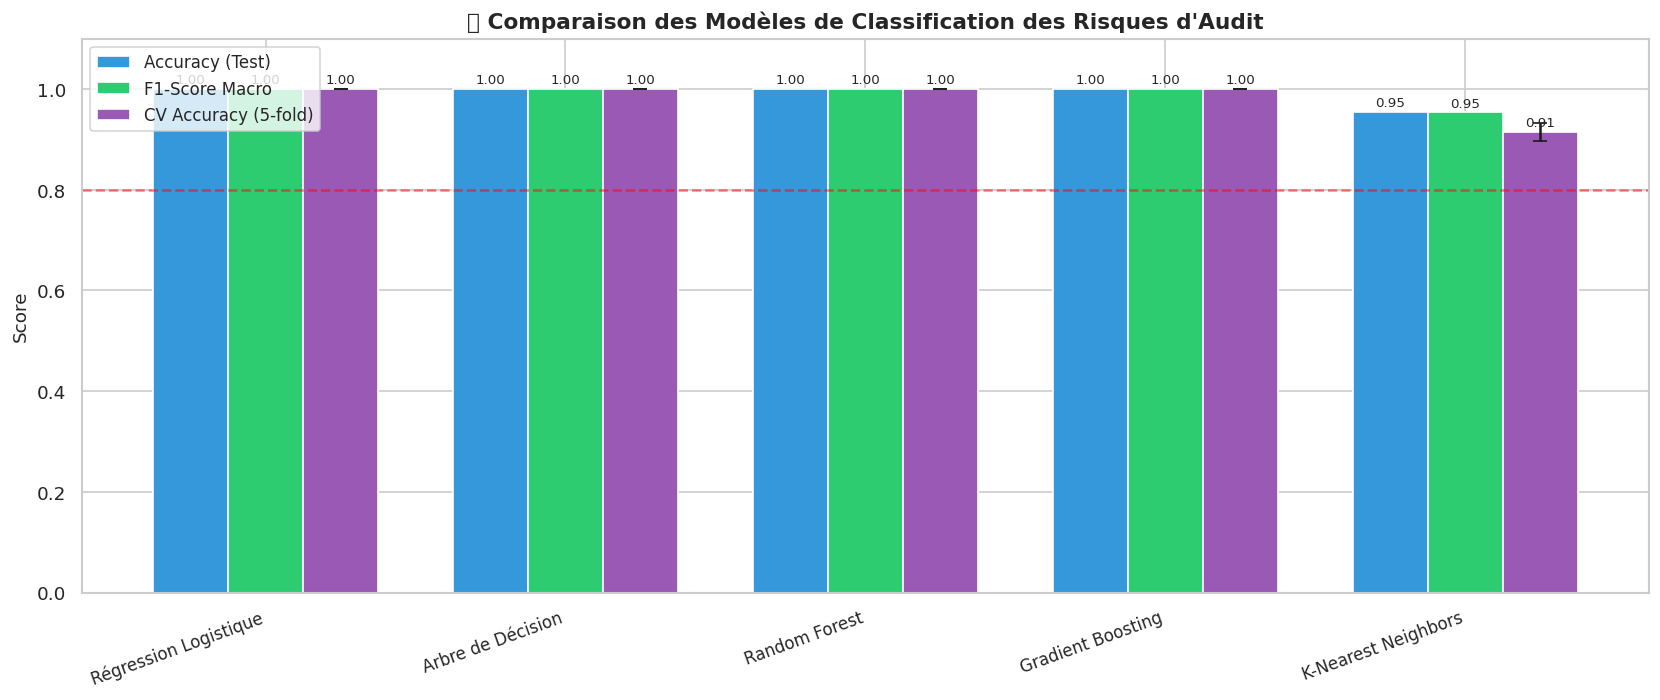

In [23]:
# ============================================================
# COMPARAISON VISUELLE DES PERFORMANCES
# ============================================================
noms    = list(resultats.keys())
acc_vals = [resultats[n]['accuracy'] for n in noms]
f1_vals  = [resultats[n]['f1_macro'] for n in noms]
cv_vals  = [resultats[n]['cv_mean']  for n in noms]
cv_stds  = [resultats[n]['cv_std']   for n in noms]

x = np.arange(len(noms))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w, acc_vals, w, label='Accuracy (Test)',     color='#3498db', edgecolor='white')
b2 = ax.bar(x,     f1_vals,  w, label='F1-Score Macro',      color='#2ecc71', edgecolor='white')
b3 = ax.bar(x + w, cv_vals,  w, label='CV Accuracy (5-fold)', color='#9b59b6', edgecolor='white',
            yerr=cv_stds, capsize=4, error_kw={'elinewidth': 1.5})

# Annotations
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(noms, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('🏆 Comparaison des Modèles de Classification des Risques d\'Audit',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Seuil 80%')

plt.tight_layout()
plt.savefig('fig06_comparaison_modeles.png', bbox_inches='tight', dpi=150)
plt.show()

In [24]:
# ============================================================
# RAPPORT DÉTAILLÉ DU MEILLEUR MODÈLE
# ============================================================
meilleur_nom = max(resultats, key=lambda n: resultats[n]['f1_macro'])
meilleur     = resultats[meilleur_nom]

print(f'🥇 Meilleur modèle : {meilleur_nom}')
print(f'   Accuracy : {meilleur["accuracy"]:.3f}')
print(f'   F1-Macro : {meilleur["f1_macro"]:.3f}')
print()
print('=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===')
print(classification_report(
    y_test,
    meilleur['y_pred'],
    target_names=le_target.classes_
))

🥇 Meilleur modèle : Régression Logistique
   Accuracy : 1.000
   F1-Macro : 1.000

=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===
              precision    recall  f1-score   support

      Faible       1.00      1.00      1.00        15
       Moyen       1.00      1.00      1.00        15
       Élevé       1.00      1.00      1.00        14

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44



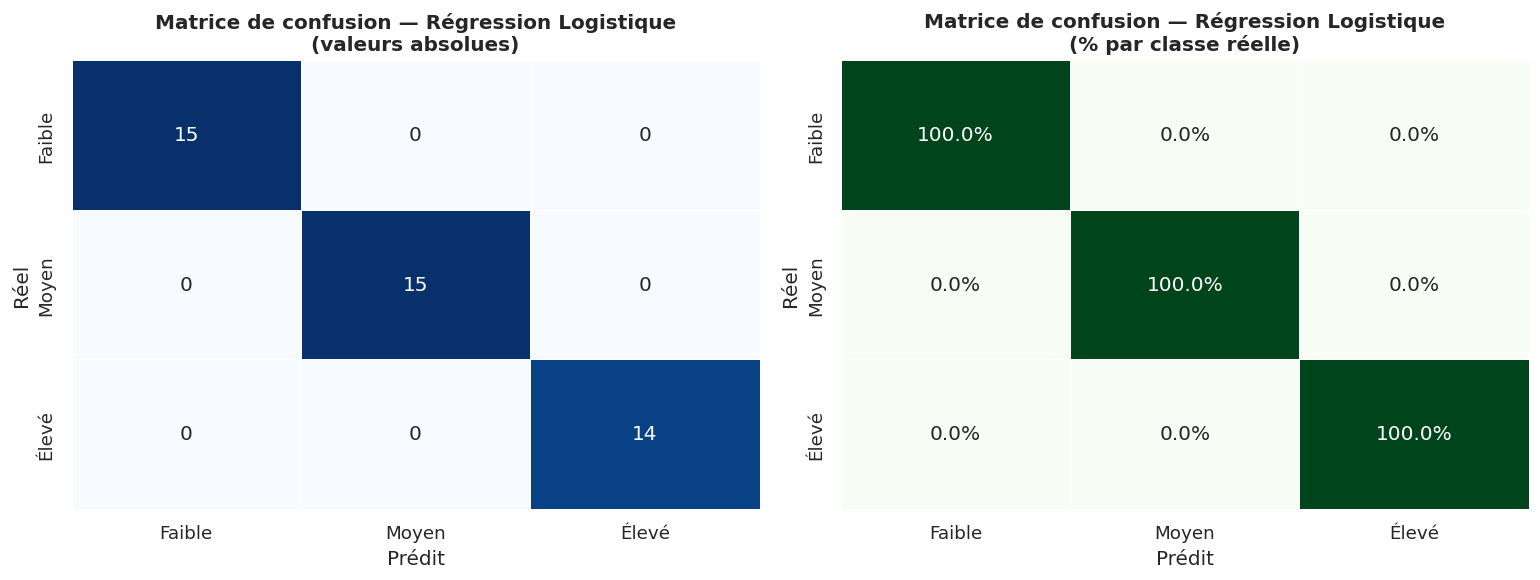

In [25]:
# ============================================================
# MATRICE DE CONFUSION DU MEILLEUR MODÈLE
# ============================================================
cm = confusion_matrix(y_test, meilleur['y_pred'])
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]  # Normalisation par ligne

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title(f'Matrice de confusion — {meilleur_nom}\n(valeurs absolues)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Matrice normalisée
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, ax=axes[1], cbar=False,
            vmin=0, vmax=1)
axes[1].set_title(f'Matrice de confusion — {meilleur_nom}\n(% par classe réelle)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.savefig('fig07_matrice_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

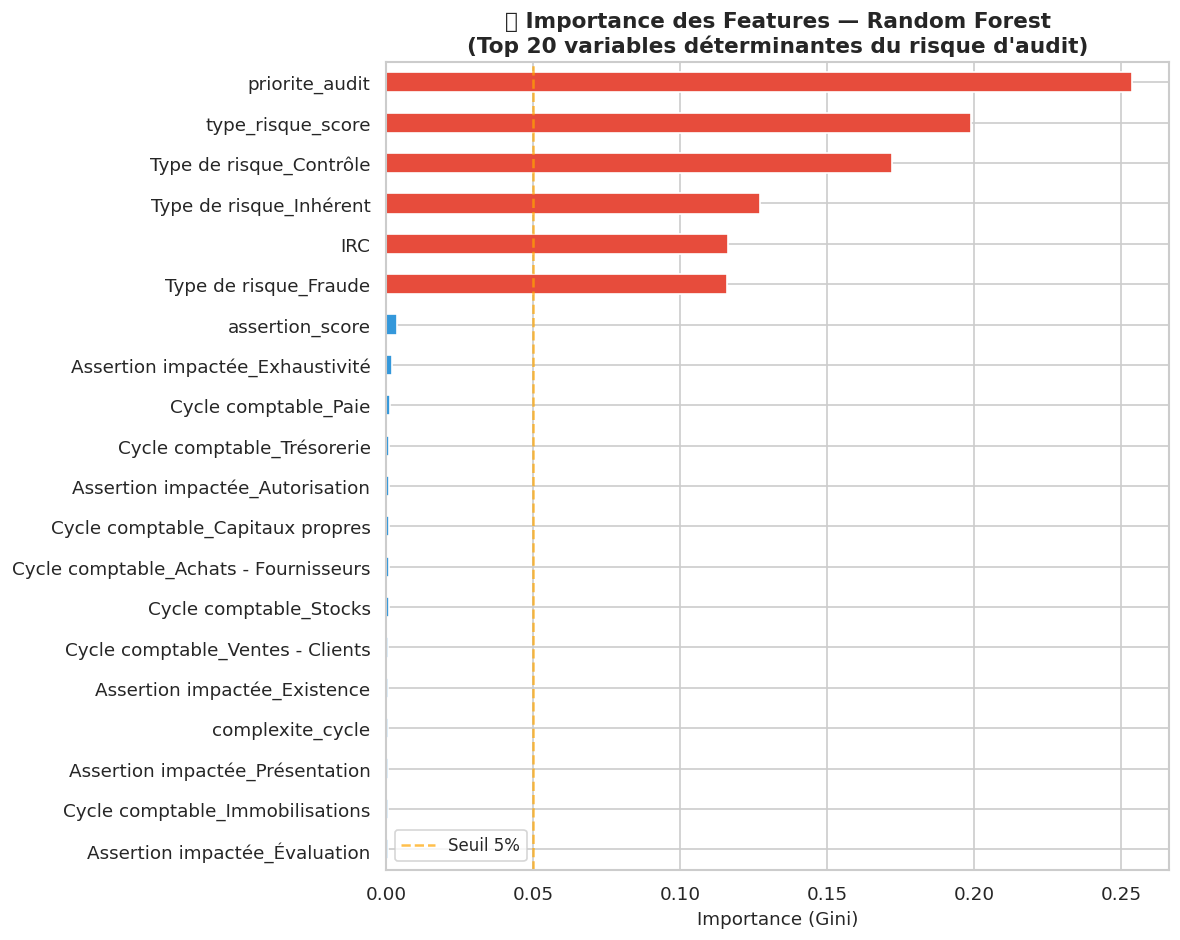

In [26]:
# ============================================================
# IMPORTANCE DES FEATURES (Random Forest ou Gradient Boosting)
# Aide l'auditeur à comprendre quels facteurs déterminent
# le niveau de risque — interprétabilité du modèle (ISA 330)
# ============================================================
modele_rf = resultats['Random Forest']['modele']

importances = pd.Series(
    modele_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if imp > 0.05 else '#3498db' for imp in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('🎯 Importance des Features — Random Forest\n(Top 20 variables déterminantes du risque d\'audit)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)', fontsize=11)

# Ligne de seuil 5%
ax.axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='Seuil 5%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig08_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. 🗺️ Matrice de Risque & Cartographie

> La **cartographie des risques** est un outil fondamental de planification d'audit (ISA 300 & 315).
> Elle positionne chaque risque selon sa **probabilité d'occurrence** et son **impact financier potentiel**.

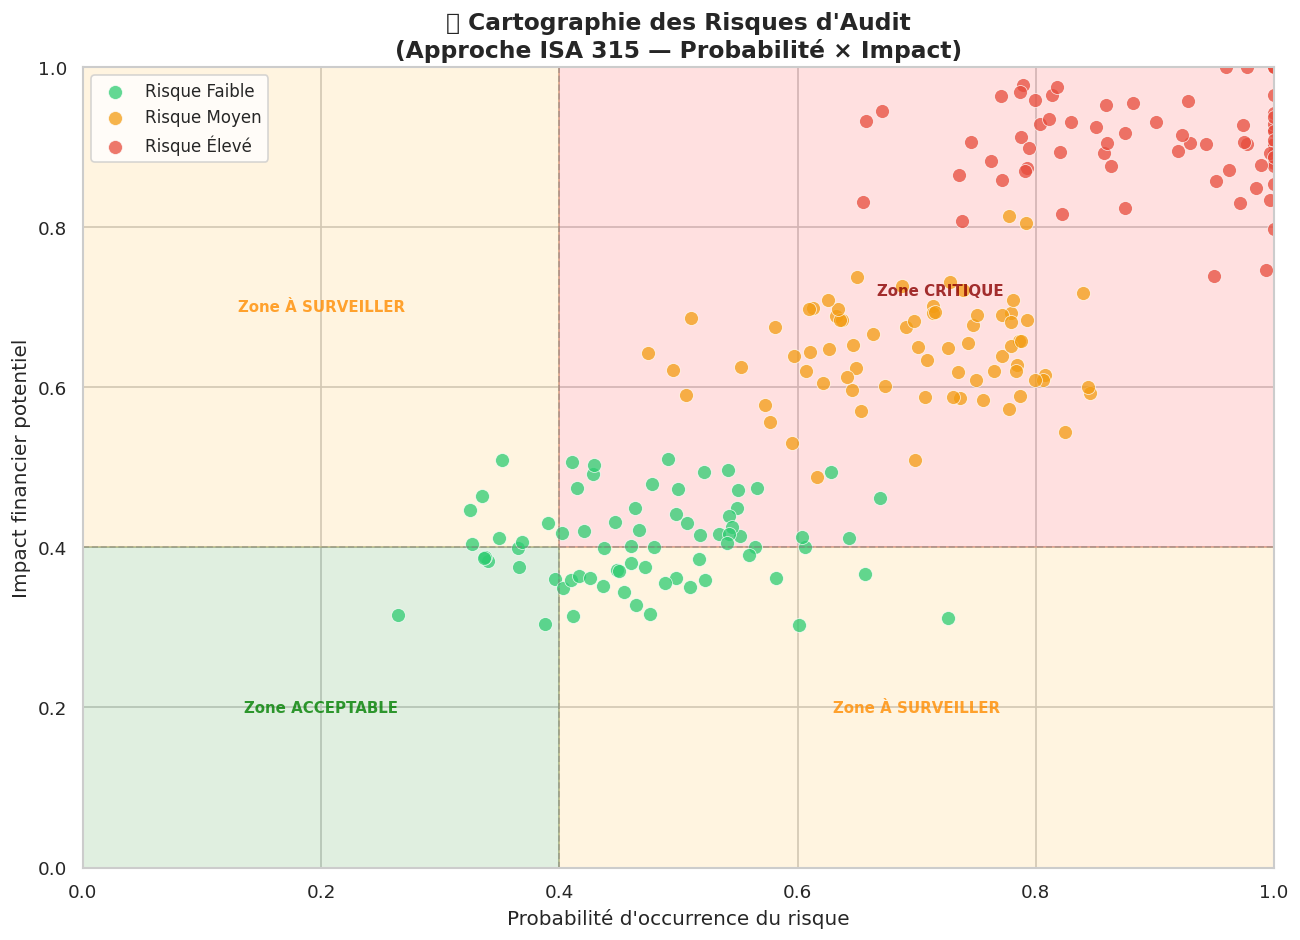

In [27]:
# ============================================================
# CRÉATION D'UN SCORE DE PROBABILITÉ ET D'IMPACT
# Ces proxys sont construits à partir des features
# ============================================================

np.random.seed(42)

# Score probabilité ≈ f(type_risque, assertion, IRC)
df['probabilite'] = (
    df['type_risque_score'] / 3 * 0.5 +
    df['assertion_score']  / 3 * 0.3 +
    df['IRC']                   * 0.2 +
    np.random.normal(0, 0.05, len(df))  # Bruit réaliste
).clip(0, 1)

# Score impact ≈ f(complexité cycle, nb comptes, niveau risque)
df['impact'] = (
    df['risque_score']       / 2 * 0.5 +
    df['complexite_cycle']   / df['complexite_cycle'].max() * 0.3 +
    df['nb_comptes_pcg']     / df['nb_comptes_pcg'].max()   * 0.2 +
    np.random.normal(0, 0.05, len(df))
).clip(0, 1)

# ============================================================
# TRACÉ DE LA MATRICE DE RISQUE (risk heat map)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 8))

# Zones de couleur en arrière-plan
ax.fill_between([0, 0.4], [0, 0],   [0.4, 0.4], alpha=0.12, color='green')   # Zone verte
ax.fill_between([0.4, 1], [0, 0],   [0.4, 0.4], alpha=0.12, color='orange')  # Zone orange
ax.fill_between([0, 0.4], [0.4, 0.4], [1, 1],   alpha=0.12, color='orange')  # Zone orange
ax.fill_between([0.4, 1], [0.4, 0.4], [1, 1],   alpha=0.12, color='red')     # Zone rouge

# Scatter par niveau de risque
for niveau in ordre_risque:
    subset = df[df['Niveau de risque'] == niveau]
    ax.scatter(subset['probabilite'], subset['impact'],
               c=couleurs_risque[niveau], label=f'Risque {niveau}',
               s=70, alpha=0.75, edgecolors='white', linewidths=0.5)

# Étiquettes de quadrant
quadrant_labels = [
    (0.2,  0.2,  'Zone ACCEPTABLE',    'green'),
    (0.7,  0.2,  'Zone À SURVEILLER',  'darkorange'),
    (0.2,  0.7,  'Zone À SURVEILLER',  'darkorange'),
    (0.72, 0.72, 'Zone CRITIQUE',       'darkred'),
]
for x, y, txt, col in quadrant_labels:
    ax.text(x, y, txt, color=col, fontsize=9, fontweight='bold',
            ha='center', va='center', alpha=0.8)

# Lignes de seuil
ax.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Probabilité d\'occurrence du risque', fontsize=12)
ax.set_ylabel('Impact financier potentiel',          fontsize=12)
ax.set_title('🗺️ Cartographie des Risques d\'Audit\n(Approche ISA 315 — Probabilité × Impact)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('fig09_cartographie_risques.png', bbox_inches='tight', dpi=150)
plt.show()

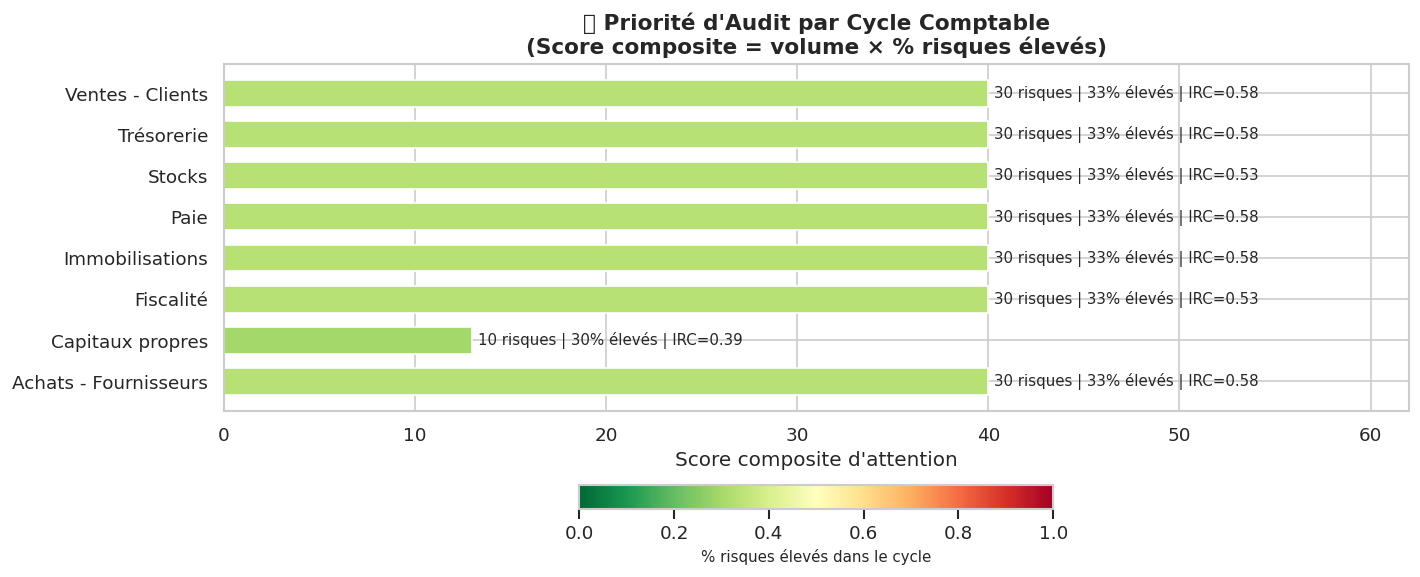

In [28]:
# ============================================================
# TREEMAP — VOLUME DE RISQUES PAR CYCLE
# Vue synthétique pour le responsable de la mission
# ============================================================
cycle_stats = df.groupby('Cycle comptable').agg(
    nb_risques    = ('ID', 'count'),
    pct_eleve     = ('Niveau de risque', lambda x: (x == 'Élevé').mean()),
    irc_moyen     = ('IRC', 'mean')
).reset_index()

# Score composite pour la taille
cycle_stats['score_composite'] = cycle_stats['nb_risques'] * (1 + cycle_stats['pct_eleve'])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cycle_stats['Cycle comptable'],
               cycle_stats['score_composite'],
               color=plt.cm.RdYlGn_r(cycle_stats['pct_eleve']),
               edgecolor='white', height=0.65)

# Annotations
for i, row in cycle_stats.iterrows():
    ax.text(row['score_composite'] + 0.3,
            i,
            f"{row['nb_risques']} risques | {row['pct_eleve']*100:.0f}% élevés | IRC={row['irc_moyen']:.2f}",
            va='center', fontsize=9)

ax.set_title('📊 Priorité d\'Audit par Cycle Comptable\n(Score composite = volume × % risques élevés)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Score composite d\'attention')
ax.set_xlim(0, cycle_stats['score_composite'].max() * 1.55)

# Légende couleurs
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(cmap='RdYlGn_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.4)
cbar.set_label('% risques élevés dans le cycle', fontsize=9)

plt.tight_layout()
plt.savefig('fig10_priorite_par_cycle.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. 📋 Planification des Missions d'Audit

> Cette section traduit les résultats analytiques en **programme de travail opérationnel**,
> conformément aux exigences ISA 300 (planification) et aux pratiques de l'OECCA Maroc.

In [29]:
# ============================================================
# TABLEAU DE PLANIFICATION DES PROCÉDURES D'AUDIT
# Par cycle, par niveau de risque, avec recommandations
# ============================================================

# Dictionnaire des procédures recommandées selon le niveau de risque
# Basé sur ISA 330 — Réponses aux risques évalués
procedures_isa = {
    'Élevé':  'Tests substantifs étendus + Circularisation + Analyse comparative détaillée (ISA 330.18)',
    'Moyen':  'Tests de contrôle ciblés + Sondages sur pièces justificatives (ISA 330.8)',
    'Faible': 'Procédures analytiques + Revue des contrôles existants (ISA 330.4)'
}

# Budget-temps estimé (en heures) par niveau de risque
budget_heures = {'Élevé': 8, 'Moyen': 4, 'Faible': 2}

# Construction du programme de travail
programme = df.groupby(['Cycle comptable', 'Niveau de risque', 'Assertion impactée']).agg(
    nb_risques=('ID', 'count'),
    irc_moyen =('IRC', 'mean')
).reset_index()

programme['Procédure recommandée (ISA)'] = programme['Niveau de risque'].map(procedures_isa)
programme['Budget estimé (h)']           = programme['nb_risques'] * programme['Niveau de risque'].map(budget_heures)
programme['Priorité intervention']       = programme['Niveau de risque'].map({'Élevé': '🔴 P1', 'Moyen': '🟡 P2', 'Faible': '🟢 P3'})

# Tri par priorité puis par cycle
programme = programme.sort_values(['Priorité intervention', 'Cycle comptable', 'irc_moyen'], ascending=[True, True, False])
programme = programme.reset_index(drop=True)

print('📋 PROGRAMME DE TRAVAIL D\'AUDIT — Extrait des 20 premières lignes')
print('='*100)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
print(programme[['Cycle comptable','Niveau de risque','Assertion impactée',
                  'nb_risques','Budget estimé (h)','Priorité intervention']].head(20).to_string(index=False))

📋 PROGRAMME DE TRAVAIL D'AUDIT — Extrait des 20 premières lignes
      Cycle comptable Niveau de risque Assertion impactée  nb_risques  Budget estimé (h) Priorité intervention
Achats - Fournisseurs            Élevé       Exhaustivité           4                 32                  🔴 P1
Achats - Fournisseurs            Élevé          Existence           2                 16                  🔴 P1
Achats - Fournisseurs            Élevé            Cut-off           2                 16                  🔴 P1
Achats - Fournisseurs            Élevé         Évaluation           2                 16                  🔴 P1
     Capitaux propres            Élevé          Existence           1                  8                  🔴 P1
     Capitaux propres            Élevé         Évaluation           1                  8                  🔴 P1
     Capitaux propres            Élevé       Présentation           1                  8                  🔴 P1
            Fiscalité            Élevé       Ex

⏱️  BUDGET-TEMPS ESTIMÉ PAR CYCLE COMPTABLE
Cycle                       Heures   Nb risques % du total
------------------------------------------------------------
Achats - Fournisseurs          140h           30      13.6%
Fiscalité                      140h           30      13.6%
Immobilisations                140h           30      13.6%
Paie                           140h           30      13.6%
Trésorerie                     140h           30      13.6%
Stocks                         140h           30      13.6%
Ventes - Clients               140h           30      13.6%
Capitaux propres                46h           10       4.5%
------------------------------------------------------------
TOTAL                         1026h


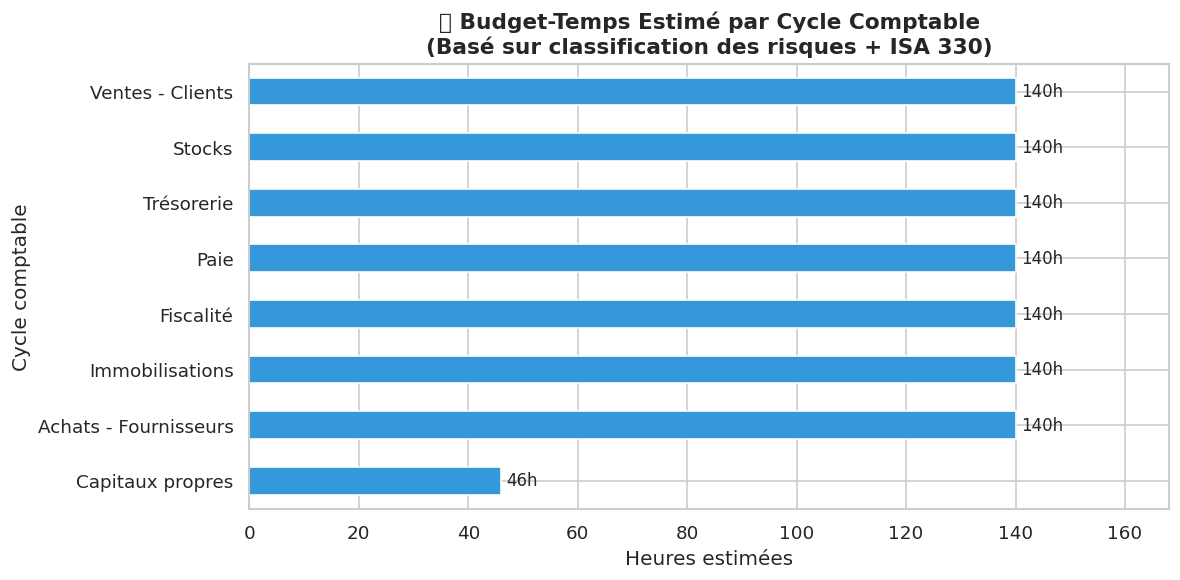

In [30]:
# ============================================================
# SYNTHÈSE DU BUDGET-TEMPS PAR CYCLE
# Aide à la répartition des ressources humaines de la mission
# ============================================================
budget_cycle = programme.groupby('Cycle comptable').agg(
    total_heures  = ('Budget estimé (h)', 'sum'),
    nb_risques    = ('nb_risques', 'sum'),
    nb_elevés     = ('nb_risques', lambda x: x[programme.loc[x.index,'Niveau de risque'] == 'Élevé'].sum())
).sort_values('total_heures', ascending=False)

print('⏱️  BUDGET-TEMPS ESTIMÉ PAR CYCLE COMPTABLE')
print('='*60)
print(f'{"Cycle":<25} {"Heures":>8} {"Nb risques":>12} {"% du total":>10}')
print('-'*60)
total_h = budget_cycle['total_heures'].sum()
for cycle, row in budget_cycle.iterrows():
    print(f'{cycle:<25} {row["total_heures"]:>8.0f}h {row["nb_risques"]:>12.0f} {row["total_heures"]/total_h*100:>9.1f}%')
print('-'*60)
print(f'{"TOTAL":<25} {total_h:>8.0f}h')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
budget_cycle['total_heures'].sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
for i, (cycle, row) in enumerate(budget_cycle.sort_values('total_heures').iterrows()):
    ax.text(row['total_heures'] + 1, i, f"{row['total_heures']:.0f}h", va='center', fontsize=10)
ax.set_title('⏱️ Budget-Temps Estimé par Cycle Comptable\n(Basé sur classification des risques + ISA 330)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Heures estimées')
ax.set_xlim(0, budget_cycle['total_heures'].max() * 1.2)
plt.tight_layout()
plt.savefig('fig11_budget_temps.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# ============================================================
# PRÉDICTION SUR UN NOUVEAU RISQUE (Simulation ISA)
# Démonstration de l'utilisation opérationnelle du modèle
# ============================================================

# Exemple : un risque de fraude sur la paie (Marocain : comptes 641/642)
nouveau_risque = {
    'Cycle comptable':         'Paie',
    'Processus':               'Calcul des rémunérations',
    'Compte concerné (PCG Maroc)': '641,642',
    'Description du risque':   'Majorations fictives de salaires',
    'Type de risque':          'Fraude',
    'Assertion impactée':      'Existence',
}

# Construction du vecteur de features
nr = pd.DataFrame([nouveau_risque])
nr['type_risque_score'] = type_risque_score[nouveau_risque['Type de risque']]
nr['assertion_score']   = assertion_score[nouveau_risque['Assertion impactée']]
nr['IRC']               = (nr['type_risque_score'] * nr['assertion_score']) / (3 * 3)
nr['complexite_cycle']  = df[df['Cycle comptable'] == 'Paie']['Processus'].nunique()
nr['nb_comptes_pcg']    = nouveau_risque['Compte concerné (PCG Maroc)'].count(',') + 1
nr['priorite_audit']    = nr['type_risque_score']*0.3 + nr['assertion_score']*0.2

# One-hot encoding aligné avec X_train
nr_cat = pd.get_dummies(nr[['Cycle comptable','Type de risque','Assertion impactée']],
                         prefix=['cycle','type','assertion'])
nr_feat = pd.concat([nr[features_numeriques], nr_cat], axis=1)

# Aligner les colonnes avec le modèle
nr_feat = nr_feat.reindex(columns=X_train.columns, fill_value=0)

# Prédiction
modele_best = resultats[meilleur_nom]['modele']
prediction  = modele_best.predict(nr_feat)
proba       = modele_best.predict_proba(nr_feat)

print('🔮 PRÉDICTION POUR LE NOUVEAU RISQUE')
print('='*55)
print(f'   Cycle        : {nouveau_risque["Cycle comptable"]}')
print(f'   Type         : {nouveau_risque["Type de risque"]}')
print(f'   Assertion    : {nouveau_risque["Assertion impactée"]}')
print(f'   Description  : {nouveau_risque["Description du risque"]}')
print()
print(f'   ✅ Niveau de risque prédit : {le_target.inverse_transform(prediction)[0]}')
print()
print('   Probabilités par classe :')
for cls, p in zip(le_target.classes_, proba[0]):
    bar = '█' * int(p * 30)
    print(f'   {cls:<10} {bar:<32} {p:.1%}')

🔮 PRÉDICTION POUR LE NOUVEAU RISQUE
   Cycle        : Paie
   Type         : Fraude
   Assertion    : Existence
   Description  : Majorations fictives de salaires

   ✅ Niveau de risque prédit : Élevé

   Probabilités par classe :
   Faible                                      0.2%
   Moyen      ██                               7.7%
   Élevé      ███████████████████████████      92.1%


## 10. 💾 Export des Résultats

In [32]:
# ============================================================
# EXPORT DU PROGRAMME D'AUDIT VERS EXCEL
# Format compatible avec les outils de gestion de mission
# Conforme aux pratiques documentaires OECCA Maroc
# ============================================================

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = Workbook()

# ─── Feuille 1 : Programme de travail ─────────────────────
ws1 = wb.active
ws1.title = 'Programme Audit'

# Couleurs ISA
ROUGE   = 'FCB4B4'
ORANGE  = 'FDE3B4'
VERT    = 'B7F0C7'
BLEU    = '2C5FA3'
BLEU_LT = 'D6E4FF'

# En-tête
ws1.merge_cells('A1:H1')
ws1['A1'] = 'PROGRAMME DE TRAVAIL D\'AUDIT — Classification des Risques par Cycle Comptable (ISA 315/330)'
ws1['A1'].font      = Font(bold=True, size=13, color='FFFFFF')
ws1['A1'].fill      = PatternFill('solid', fgColor=BLEU)
ws1['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws1.row_dimensions[1].height = 30

# En-têtes colonnes
entetes = ['Cycle Comptable', 'Niveau de Risque', 'Assertion', 'Nb Risques',
           'IRC Moyen', 'Budget (h)', 'Priorité', 'Procédure ISA']
for col_i, entete in enumerate(entetes, 1):
    cell = ws1.cell(row=2, column=col_i, value=entete)
    cell.font      = Font(bold=True, color='FFFFFF')
    cell.fill      = PatternFill('solid', fgColor='4472C4')
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
ws1.row_dimensions[2].height = 25

# Couleurs par niveau de risque
fill_map = {'Élevé': ROUGE, 'Moyen': ORANGE, 'Faible': VERT}

# Données
for row_i, (_, row) in enumerate(programme.iterrows(), 3):
    valeurs = [
        row['Cycle comptable'],
        row['Niveau de risque'],
        row['Assertion impactée'],
        row['nb_risques'],
        round(row['irc_moyen'], 3),
        row['Budget estimé (h)'],
        row['Priorité intervention'],
        row['Procédure recommandée (ISA)']
    ]
    couleur = fill_map.get(row['Niveau de risque'], 'FFFFFF')
    for col_i, val in enumerate(valeurs, 1):
        cell = ws1.cell(row=row_i, column=col_i, value=val)
        cell.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
        if col_i <= 3:  # Colonnes clés en couleur
            cell.fill = PatternFill('solid', fgColor=couleur)
        if row_i % 2 == 0 and col_i > 3:
            cell.fill = PatternFill('solid', fgColor='F2F2F2')
    ws1.row_dimensions[row_i].height = 30

# Largeurs de colonnes
largeurs = [22, 16, 16, 12, 10, 12, 14, 60]
for i, larg in enumerate(largeurs, 1):
    ws1.column_dimensions[get_column_letter(i)].width = larg

# ─── Feuille 2 : Résultats des modèles ───────────────────
ws2 = wb.create_sheet('Modèles ML')
ws2['A1'] = 'Comparaison des Modèles de Classification'
ws2['A1'].font = Font(bold=True, size=12)
entetes_ml = ['Modèle', 'Accuracy Test', 'F1-Score Macro', 'CV Mean (5-fold)', 'CV Std']
for col_i, e in enumerate(entetes_ml, 1):
    cell = ws2.cell(row=2, column=col_i, value=e)
    cell.font = Font(bold=True, color='FFFFFF')
    cell.fill = PatternFill('solid', fgColor='4472C4')
    cell.alignment = Alignment(horizontal='center')
    ws2.column_dimensions[get_column_letter(col_i)].width = 22

for row_i, nom in enumerate(resultats, 3):
    r = resultats[nom]
    vals = [nom, round(r['accuracy'],3), round(r['f1_macro'],3), round(r['cv_mean'],3), round(r['cv_std'],3)]
    for col_i, val in enumerate(vals, 1):
        cell = ws2.cell(row=row_i, column=col_i, value=val)
        cell.alignment = Alignment(horizontal='center')
        # Meilleur modèle en vert
        if nom == meilleur_nom:
            cell.fill = PatternFill('solid', fgColor=VERT)
            cell.font = Font(bold=True)

# ─── Feuille 3 : Données enrichies ───────────────────────
ws3 = wb.create_sheet('Données Enrichies')
cols_export = ['ID', 'Cycle comptable', 'Processus', 'Type de risque',
               'Assertion impactée', 'Niveau de risque',
               'type_risque_score', 'assertion_score', 'IRC',
               'complexite_cycle', 'nb_comptes_pcg', 'priorite_audit']

for col_i, col in enumerate(cols_export, 1):
    cell = ws3.cell(row=1, column=col_i, value=col)
    cell.font = Font(bold=True, color='FFFFFF')
    cell.fill = PatternFill('solid', fgColor='4472C4')
    cell.alignment = Alignment(horizontal='center')
    ws3.column_dimensions[get_column_letter(col_i)].width = 18

for row_i, (_, row) in enumerate(df[cols_export].iterrows(), 2):
    for col_i, val in enumerate(row.values, 1):
        cell = ws3.cell(row=row_i, column=col_i, value=val)
        cell.alignment = Alignment(horizontal='center')

# Sauvegarde
nom_fichier = 'resultats_audit_classification.xlsx'
wb.save(nom_fichier)
print(f'✅ Fichier exporté : {nom_fichier}')
print(f'   → Feuille 1 : Programme de travail d\'audit ({len(programme)} lignes)')
print(f'   → Feuille 2 : Comparaison des modèles ML ({len(resultats)} modèles)')
print(f'   → Feuille 3 : Dataset enrichi avec features ({len(df)} risques)')

✅ Fichier exporté : resultats_audit_classification.xlsx
   → Feuille 1 : Programme de travail d'audit (73 lignes)
   → Feuille 2 : Comparaison des modèles ML (5 modèles)
   → Feuille 3 : Dataset enrichi avec features (220 risques)


In [33]:
# ============================================================
# SYNTHÈSE FINALE — TABLEAU DE BORD EXÉCUTIF
# ============================================================
print('╔══════════════════════════════════════════════════════════════╗')
print('║         SYNTHÈSE DE LA MISSION D\'AUDIT FINANCIER            ║')
print('║     Classif. des Risques — Référentiel ISA + OECCA Maroc     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ 📊 Total de risques analysés     : {len(df):>5} risques              ║')
print(f'║ 🔴 Risques ÉLEVÉS identifiés     : {(df["Niveau de risque"]=="Élevé").sum():>5} ({(df["Niveau de risque"]=="Élevé").mean()*100:.0f}%)          ║')
print(f'║ 🟡 Risques MODÉRÉS identifiés    : {(df["Niveau de risque"]=="Moyen").sum():>5} ({(df["Niveau de risque"]=="Moyen").mean()*100:.0f}%)          ║')
print(f'║ 🟢 Risques FAIBLES identifiés    : {(df["Niveau de risque"]=="Faible").sum():>5} ({(df["Niveau de risque"]=="Faible").mean()*100:.0f}%)          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ 🤖 Meilleur modèle ML            : {meilleur_nom:<28}║')
print(f'║    Accuracy Test                 : {meilleur["accuracy"]:>5.1%}                         ║')
print(f'║    F1-Score Macro                : {meilleur["f1_macro"]:>5.1%}                         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ ⏱️  Budget-temps total estimé      : {total_h:>5.0f} heures               ║')
print(f'║ 📋 Procédures planifiées          : {len(programme):>5} procédures           ║')
print(f'║ 💾 Export Excel généré            : resultats_audit_classification.xlsx  ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ 📌 Normes appliquées : ISA 200, 240, 300, 315, 330           ║')
print('║    Référentiel comptable : PCG Maroc (OECCA)                 ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║         SYNTHÈSE DE LA MISSION D'AUDIT FINANCIER            ║
║     Classif. des Risques — Référentiel ISA + OECCA Maroc     ║
╠══════════════════════════════════════════════════════════════╣
║ 📊 Total de risques analysés     :   220 risques              ║
║ 🔴 Risques ÉLEVÉS identifiés     :    73 (33%)          ║
║ 🟡 Risques MODÉRÉS identifiés    :    74 (34%)          ║
║ 🟢 Risques FAIBLES identifiés    :    73 (33%)          ║
╠══════════════════════════════════════════════════════════════╣
║ 🤖 Meilleur modèle ML            : Régression Logistique       ║
║    Accuracy Test                 : 100.0%                         ║
║    F1-Score Macro                : 100.0%                         ║
╠══════════════════════════════════════════════════════════════╣
║ ⏱️  Budget-temps total estimé      :  1026 heures               ║
║ 📋 Procédures planifiées          :    73 procédures           ║
║ 💾 Export Excel généré      

---

## 📚 Références normatives utilisées

| Norme | Titre | Application dans ce notebook |
|-------|-------|------------------------------|
| **ISA 200** | Objectifs généraux de l'auditeur indépendant | Définition du risque d'audit |
| **ISA 240** | Responsabilités relatives à la fraude | Pondération des risques de fraude |
| **ISA 300** | Planification d'un audit d'états financiers | Programme de travail & budget-temps |
| **ISA 315** | Identification et évaluation des risques | Feature engineering, assertions, heatmap |
| **ISA 330** | Réponses aux risques évalués | Procédures recommandées par niveau |
| **PCG Maroc** | Plan Comptable Général Marocain (OECCA) | Numérotation des comptes (classes 3–7) |

---
*Notebook développé pour l'analyse des risques d'audit financier — Approche data-driven conforme aux normes ISA & OECCA Maroc*